In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd

In [6]:
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
X= df.drop(columns="MEDV")
y = df["MEDV"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Standardization

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [10]:
X_test = scaler.transform(X_test)

Model training

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(model, X_train, y_train, cv=20, scoring='neg_mean_squared_error')

print(scores)
print(scores.mean())

[-12.45972911 -15.09996226 -15.93126229 -22.74731141 -30.82494857
 -26.01320713 -73.60421605 -15.33574177 -16.1706719  -27.38888843
 -32.46024729 -24.51704911 -21.26264919 -16.31629089 -18.80696567
 -22.83855948 -13.74752805 -12.9729264  -14.9264194  -52.16882394]
-24.279669917457745


In [14]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Prediciting and comparing data using Distplot(used to visualize the distribution of a dataset, showing how values are spread.)

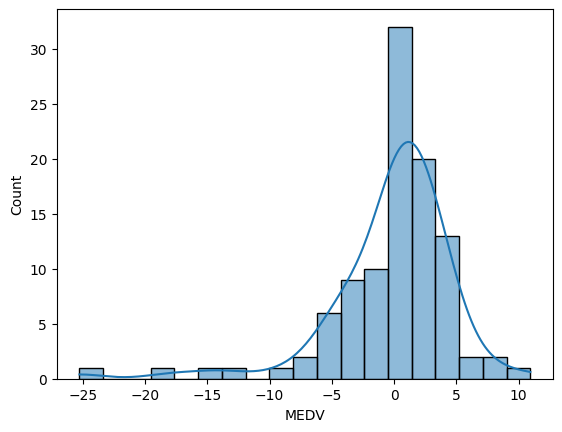

24.235505485277034


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_pred - y_test, kde=True)
plt.show()


residuals = y_pred - y_test
variance = np.var(residuals)

print(variance)

In [24]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.668759493535632
